PROJET MACHINE LEARNING :

Reconnaissance de l'alphabet en langue des signes américaine 

Choix des datasets :

1) https://www.kaggle.com/datasets/kapillondhe/american-sign-language/data
2) https://www.kaggle.com/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/data

V1 : Explications et procédes.

Au départ, nous comptions essayer de faire de la classification multi-label en se basant uniquement sur des images brutes.
Nous avons trouvé le dataset (1) contentant pour 28 caractères (26 lettres, espace, rien) 6000 images de 400x400px.
Nous avions pris la décision de passer ces images en noir et blanc pour réduire leur taille par 3. Malgré ces changements, le dataset était assez lourd et les  calculs étaient lents, donc on a réduit chaque image à un format de 128x128px.

Les premiers résultats étaient assez satfisaifants, mais lorsque nous faisions des tests avec des images qu'on importait, le modèle se trompait systématiquement. 
Notre analyse a donc été de dire que c'était à cause du dataset, dont les images sont toutes quasiment identiques, et que nous étions confrontés à de l'overfitting.

On a donc trouvé le dataset (2) et on a pris pour chaque caractère 6000 images de chaque dataset (12000*28 images en tout)

V2 :

Pour palier les problèmes de chargement des datasets et d'entraînement des modèles qui étaient très long en raison du grand nombre de données, nous avons décidé d'utiliser le pipeline mediapipe de Google afin de détecter les positions des points importants de la main.

Mediapipe : https://mediapipe.org

Ci-dessous le pipeline officiel de mediapipe pour de la reconnaissance de gestes

In [15]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
#from google.colab.patches import cv2_imshow
import cv2
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.models import load_model, Sequential # type: ignore
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout, BatchNormalization # type: ignore
from tensorflow.keras.callbacks import EarlyStopping #type: ignore
from sklearn.utils import shuffle
import csv
import os
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef, cohen_kappa_score, log_loss, roc_auc_score
import seaborn as sns
import pandas as pd


In [6]:
model_path = "hand_landmarker.task"
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),        # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),        # Index
    (0, 9), (9, 10), (10, 11), (11, 12),   # Middle
    (0, 13), (13, 14), (14, 15), (15, 16), # Ring
    (0, 17), (17, 18), (18, 19), (19, 20), # Pinky
    (5, 9), (9, 13), (13, 17)              # Palm connections
]

def to_pixel(x_norm: float, y_norm: float, w: int, h: int) -> tuple[int, int]:
    # keep to [0,1] to avoid occasional out-of-range artifacts
    x = min(max(x_norm, 0.0), 1.0)
    y = min(max(y_norm, 0.0), 1.0)
    return int(x * w), int(y * h)

def draw_hand_landmarks_tasks_only(
    image_bgr: np.ndarray,
    hand_landmarks_list,
    connections=HAND_CONNECTIONS,
    draw_points=True,
    draw_connections=True,
    point_radius=3,
    point_thickness=-1,
    line_thickness=2,
):
    annotated = image_bgr.copy()
    h, w = annotated.shape[:2]

    for hand_landmarks in hand_landmarks_list:
        # Convert normalized landmarks to pixel coords
        pts = [to_pixel(lm.x, lm.y, w, h) for lm in hand_landmarks]

        if draw_connections:
            for a, b in connections:
                cv2.line(annotated, pts[a], pts[b], (0, 255, 0), line_thickness)

        if draw_points:
            for (x, y) in pts:
                cv2.circle(annotated, (x, y), point_radius, (0, 0, 255), point_thickness)

    return annotated

def run_hand_landmarker_on_image_tasks_only(image_path: str):
    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.HandLandmarkerOptions(
        base_options=base_options,
        num_hands=2,
        min_hand_detection_confidence=0.5,
        running_mode=vision.RunningMode.IMAGE
    )

    with vision.HandLandmarker.create_from_options(options) as landmarker:
        cv_image = cv2.imread(image_path)
        if cv_image is None:
            print("Image not found:", image_path)
            return

        rgb_image = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)

        result = landmarker.detect(mp_image)

    if result.hand_landmarks:
        annotated = draw_hand_landmarks_tasks_only(cv_image, result.hand_landmarks)
        cv2.namedWindow("image", cv2.WINDOW_NORMAL)
        cv2.resizeWindow("image", 800, 800)
        cv2.imshow("image", annotated)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        

    else:
        print("No hands detected.")

run_hand_landmarker_on_image_tasks_only("Dataset1\ASL_Dataset\Train\A\8.jpg")

Image not found: Dataset1\ASL_Dataset\Train\A\8.jpg


Nous avons donc récupéré ce pipeline et nous l'avons adapté afin d'extraire de chacune des images les coordonnées des 21 points de la main identifiés par mediapipe.
(Les fonctions du pipeline mediapipe ont été ajustées pour mieux correspondre à nos besoins)

In [7]:
def to_pixel(x_norm: float, y_norm: float, w: int, h: int) -> tuple[int, int]:
    # keep to [0,1] to avoid occasional out-of-range artifacts
    x = min(max(x_norm, 0.0), 1.0)
    y = min(max(y_norm, 0.0), 1.0)
    return int(x * w), int(y * h)

def draw_hand_landmarks_tasks_only(
    image_bgr: np.ndarray,
    hand_landmarks_list,
    connections=HAND_CONNECTIONS,
    draw_points=True,
    draw_connections=True,
    point_radius=3,
    point_thickness=-1,
    line_thickness=2,
):
    annotated = image_bgr.copy()
    h, w = annotated.shape[:2]

    for hand_landmarks in hand_landmarks_list:
        # Convert normalized landmarks to pixel coords
        pts = [to_pixel(lm.x, lm.y, w, h) for lm in hand_landmarks]

        if draw_connections:
            for a, b in connections:
                cv2.line(annotated, pts[a], pts[b], (0, 255, 0), line_thickness)

        if draw_points:
            for (x, y) in pts:
                cv2.circle(annotated, (x, y), point_radius, (0, 0, 255), point_thickness)

    return annotated

def run_hand_landmarker_on_image_tasks_only(image_path: str):
    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.HandLandmarkerOptions(
        base_options=base_options,
        num_hands=2,
        min_hand_detection_confidence=0.5,
        running_mode=vision.RunningMode.IMAGE
    )

    with vision.HandLandmarker.create_from_options(options) as landmarker:
        cv_image = cv2.imread(image_path)
        if cv_image is None:
            print("Image not found:", image_path)
            return

        rgb_image = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)

        result = landmarker.detect(mp_image)

    if result.hand_landmarks:
        return result.hand_landmarks
        #annotated = draw_hand_landmarks_tasks_only(cv_image, result.hand_landmarks)
        

    else:
        #print("No hands detected.")
        return 


def split_landmarks(landmarks):
    points_list = []
    for i in range(len(landmarks[0])):
        points_list.append(np.array([landmarks[0][i].x, landmarks[0][i].y, landmarks[0][i].z]))
    return np.array(points_list)

def pipe_folder(folder, label, nb_images):
    counter = 0
    fail_counter = 0
    CSV_FILENAME = "_csv/Train/" + label +".csv"
    with open(CSV_FILENAME, mode="w", newline="", encoding="utf-8") as csv_file:
        writer = csv.writer(csv_file)

        images = [img for img in os.listdir(folder+label+"/")]
        sample_img = random.sample(images, nb_images)

        for filename in sample_img:
            image_path = os.path.join(folder + label, filename)
            counter += 1
            points = run_hand_landmarker_on_image_tasks_only(image_path)
            
            if points :
                split_points = split_landmarks(points)
                #points_normalises = normalize_landmarks_rotation_invariant(split_points)
                writer.writerow(points)
                #writer.writerow(points_normalises)
            else :
                fail_counter += 1
        csv_file.flush()
        csv_file.close()
    print(label, "over")
    success = (counter-fail_counter)/counter
    print("success_rate ", success, " --- total :", counter, ", fails :", fail_counter)
    return(nb_images - fail_counter)

Pour rendre le système invariant à la translation et à la rotation, nous avons normalisé les coordonnées des points. 
Pour ce faire, on a choisi le point 0 comme origine du repère.
On définit l'axe x à l'aide de l'index, et z à l'aide de l'auriculaire.

In [8]:
def normalize_landmarks_rotation_invariant(X20: np.ndarray) -> np.ndarray:

    # Définition de l'origine
    wrist = X20[0]
    Xc = X20 - wrist

    # Définition des axes
    v1 = Xc[5]   # direction index
    v2 = Xc[17]  # direction auriculaire

    # Axe X
    x_axis = v1 / (np.linalg.norm(v1) + 1e-8)

    # Axe Z (perpendiculaire au plan de la paume)
    z_axis = np.cross(v1, v2)
    z_axis /= (np.linalg.norm(z_axis) + 1e-8)

    # Axe Y (orthogonal aux deux autres)
    y_axis = np.cross(z_axis, x_axis)

    # Matrice de rotation
    R = np.stack([x_axis, y_axis, z_axis], axis=1)  # (3,3)

    # Rotation
    Xr = Xc @ R

    # Normalisation
    scale = np.linalg.norm(Xr[8]) + 1e-8
    Xn = Xr / scale

    return Xn

Une fois ces fonctions définies, nous avons pu commencer l'extraction des données de chaque image.
Pour notre dataset, nous comptions utiliser les 12000 images, avec 60% de train, 20% de test et 20% de validation.
On a donc lancé l'extraction sur 7200 images du dataset, tirées aléatoirement parmi les 12000.
L'extraction dépandant de la capacité de mediapipe à situer les 21 points de la main, nous avons réussi à extraire entre 7200 et 3453 nuages de points en fonction des caractères (voir notes.txt pour les logs de ce process).
L'exécution a duré plus de 4h30.
À la fin, nous avions 28 fichiers csv contenant entre 3500 et 7200 images.

Au vu du temps que ça nous a pris d'extraire ces données, on a décidé de restreindre notre jeu de données à seulement 3000 images par lettre, en conservant le ration de 60/20/20.

Pour consulter le dataset, regarder dans DATASET_CSV

Le choix du format csv était d'ailleurs une erreur car nous avons passé beaucoup de temps à corriger le format des données, comme on ne stock que des textes et non des listes par exemple.

Après différents reformattages des données, nous sommes arrivés à la version finale de ces csv, contenant nos données au format que l'on désirait.

Le modèle :

In [9]:
dataset = "DATASET_CSV/"
train_folder = dataset + "Train/"
test_folder = dataset + "Test/"
val_folder = dataset + "Validation/"

### PARAMETRES

nb_img = 1800
nb_test = 600
nb_val = 600


list_char = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'Space', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

### FIN PARAMETRES

def csv_to_array(input_path):

    X = []
    with open(input_path, mode='r', newline='', encoding='utf-8') as infile :
        
        reader = csv.reader(infile)
        for row in reader:
            new_row = []
            for array in row:
                new_array = array.replace('[', '').replace(']','').replace(',', '').split(' ')
                new_array = [float(i) for i in new_array]
                new_row.append(new_array)
            X.append(new_row)
    return np.array(X)




def load_set_label(dir, lim, label):
    
    X = csv_to_array(dir + label + ".csv")[:lim]
    Y = np.array([list_char.index(label)]*lim)

    return X,Y


def load_set(dir, lim, list_labels):
    X, Y = load_set_label(dir, lim, list_labels[0])
    for label in list_labels[1:]:
        Nx, Ny = load_set_label(dir, lim, label)
        X = np.concatenate((X, Nx), axis=0)
        Y = np.concatenate((Y, Ny), axis=0)

    return np.array(X), np.array(Y)

X_train, Y_train = load_set(train_folder, nb_img, list_char)
X_test, Y_test = load_set(test_folder, nb_test, list_char)
X_val, Y_val = load_set(val_folder, nb_val, list_char)



X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)


X_train_flat = X_train.reshape(X_train.shape[0], -1)  # (n_samples, 63)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)


print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)
print(X_val.shape, Y_val.shape)

X_train, Y_train = shuffle(X_train, Y_train, random_state=42)

print(f"size training set {len(X_train)}")
print(f"size test set {len(X_test)}")
print(f"dimension {len(X_train[0])} x {len(X_train[0][0])}")



model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(21,3)),
    BatchNormalization(),
    Dropout(0.3),
    
    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(27, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor='val_accuracy', 
    patience=3,           # stop si aucune amélioration pendant 3 epochs
    restore_best_weights=True
)

model.summary()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, Y_train, batch_size=64, epochs = 30, validation_data = (X_val, Y_val), callbacks=[early_stop])

print("\nEvaluation")
model.evaluate(X_test, Y_test)


#model.save("ASL_model.keras")

(48600, 21, 3, 1) (48600,)
(16200, 21, 3, 1) (16200,)
(16200, 21, 3, 1) (16200,)
size training set 48600
size test set 16200
dimension 21 x 3


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 19, 64)         │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 19, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 17, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 17, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2176)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       278,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 308,251 (1.18 MB)

 Trainable params: 307,867 (1.17 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8629 - loss: 0.4630 - val_accuracy: 0.9476 - val_loss: 0.1818
Epoch 2/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9319 - loss: 0.2293 - val_accuracy: 0.9611 - val_loss: 0.1381
Epoch 3/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9442 - loss: 0.1856 - val_accuracy: 0.9589 - val_loss: 0.1327
Epoch 4/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9493 - loss: 0.1634 - val_accuracy: 0.9622 - val_loss: 0.1294
Epoch 5/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9542 - loss: 0.1488 - val_accuracy: 0.9657 - val_loss: 0.1166
Epoch 6/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9567 - loss: 0.1392 - val_accuracy: 0.9657 - val_loss: 0.1162
Epoch 7/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9583 - loss: 0.1303 - val_accuracy: 0.9687 - val_loss: 0.1085
Epoch 8/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9599 - loss: 0.1273 - val_accuracy: 0.

[0.08598822355270386, 0.9797530770301819]

à noter ici la suppression du caractère nothing : en effet, losqu'aucune main n'est détéctée par mediapipe, il n'extrait pas de tableau de coordonnées.

Prédiction :

In [10]:
model = load_model("ASL_model.keras")

# Chemin de l'image à prédire
image_path = "IMAGES_TEST/T.jpg"

points = run_hand_landmarker_on_image_tasks_only(image_path)

if points :
    split_points = split_landmarks(points)
    points_normalises = normalize_landmarks_rotation_invariant(split_points)
else : print("err")

print(points_normalises.shape)




# Ajouter la dimension batch et canal
points_normalises = np.expand_dims(points_normalises, axis=-1)  # (H, W, 1)
points_normalises = np.expand_dims(points_normalises, axis=0)   # (1, H, W, 1)

pred = model.predict(points_normalises) #renvoie un tableau de probabilités
print("pred")
print(pred[0])
maxi = max(pred[0])
print("max")
print(maxi)
i = list(pred[0]).index(maxi)
print(i)
print(list_char[i]) #affiche le caractère dont la probabilité de prédiction est la plus élevée.

(21, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
pred
[7.7684880e-16 4.0235018e-20 3.6010236e-11 2.3888420e-14 3.7180092e-20
 4.1939712e-14 4.7486209e-15 3.0496906e-06 1.8703768e-06 1.3765427e-07
 3.2138208e-18 5.7760612e-03 1.6732948e-06 9.1874123e-02 1.7441437e-03
 3.2253333e-15 7.5879997e-11 1.9906324e-26 5.8119567e-18 2.2952363e-01
 6.3198084e-01 2.2963830e-27 1.1088025e-28 3.8071815e-20 4.5359038e-23
 3.9094381e-02 4.7117164e-17]
max
0.63198084
20
T


Évaluation et matrice de confusion

507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


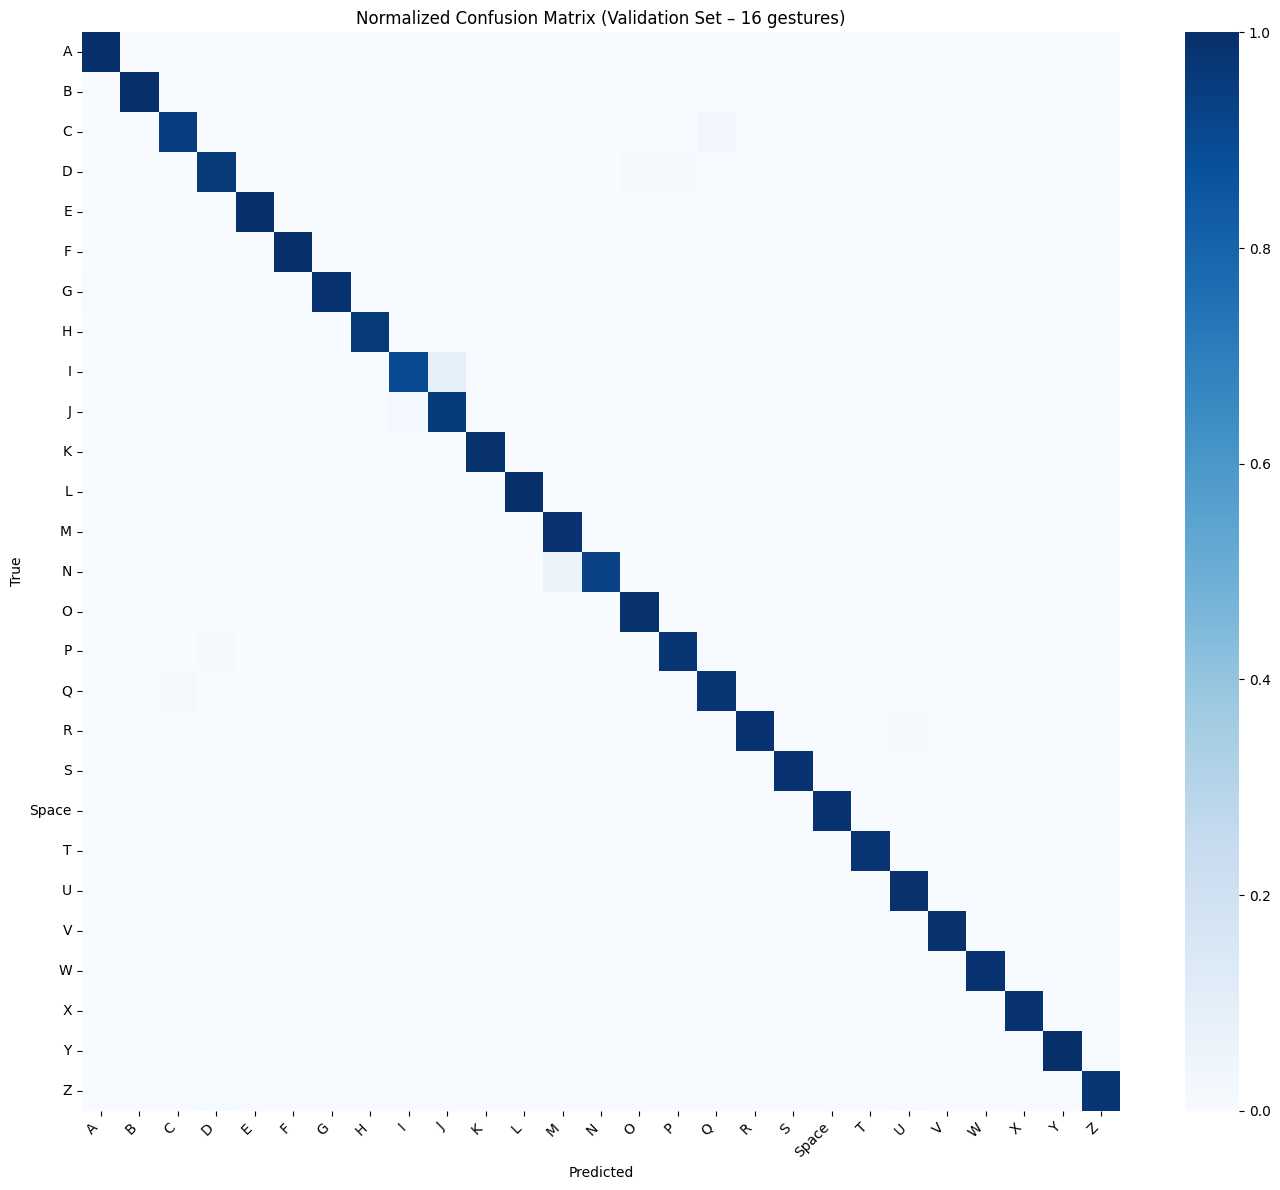

              precision  recall  f1-score    support
A                 0.984   0.998     0.991    600.000
B                 0.997   0.998     0.998    600.000
C                 0.971   0.948     0.960    600.000
D                 0.973   0.963     0.968    600.000
E                 0.977   1.000     0.988    600.000
F                 0.998   0.998     0.998    600.000
G                 0.982   0.987     0.984    600.000
H                 0.993   0.963     0.978    600.000
I                 0.970   0.902     0.934    600.000
J                 0.909   0.953     0.931    600.000
K                 0.987   0.992     0.989    600.000
L                 0.997   0.997     0.997    600.000
M                 0.929   0.985     0.956    600.000
N                 0.986   0.932     0.958    600.000
O                 0.977   0.988     0.983    600.000
P                 0.983   0.980     0.982    600.000
Q                 0.953   0.973     0.963    600.000
R                 0.990   0.985     0.987    6

In [ ]:
Y_pred = model.predict(X_val)
Y_pred_labels = np.argmax(Y_pred, axis=1)
Y_true_labels = Y_val

cm = confusion_matrix(Y_true_labels, Y_pred_labels, normalize="true")

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=list_char, yticklabels=list_char)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix (Validation Set – 16 gestures)")
plt.tight_layout()
plt.savefig("confusion_matrix_16g.png", dpi=300, bbox_inches='tight')
plt.show()

report = classification_report(Y_true_labels, Y_pred_labels, target_names=list_char, output_dict=True)

df_report = pd.DataFrame(report).transpose()

df_report = df_report.round(3)

print(df_report)

with open("classification_report_16g.tex", "w") as f:
    f.write(df_report.to_latex(index=True, float_format="%.3f"))

print("Tableau LaTeX sauvegardé : classification_report_16g.tex")

mcc = matthews_corrcoef(Y_true_labels, Y_pred_labels)
kappa = cohen_kappa_score(Y_true_labels, Y_pred_labels)
ll = log_loss(Y_true_labels, Y_pred)
auc = roc_auc_score(Y_true_labels, Y_pred, multi_class="ovr")
print(f"MCC={mcc:.4f} | Kappa={kappa:.4f} | LogLoss={ll:.4f} | MacroAUC={auc:.4f}")

metrics_table = pd.DataFrame({
    "Metric": ["MCC", "Cohen's Kappa", "Log Loss", "Macro AUC"],
    "Value": [mcc, kappa, ll, auc]
})

metrics_table["Value"] = metrics_table["Value"].round(4)

print(metrics_table)

with open("global_metrics.tex", "w") as f:
    f.write(metrics_table.to_latex(index=False))

print("Tableau LaTeX enregistré dans global_metrics.tex")